# Luminosity Schechter

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Luminosity sampling

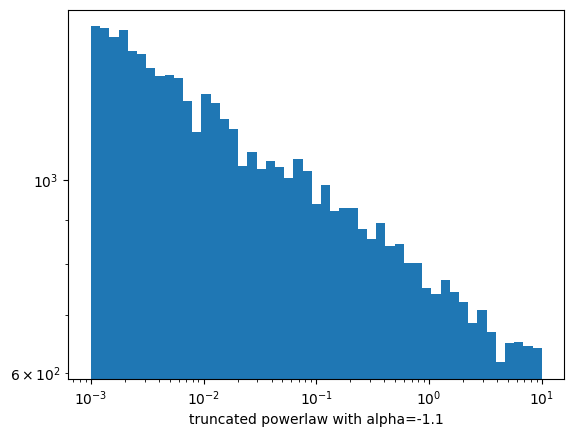

In [3]:
x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=bins);
plt.yscale('log');
plt.xscale('log');

#### Schechter ratio:

Number of rejects = 14602


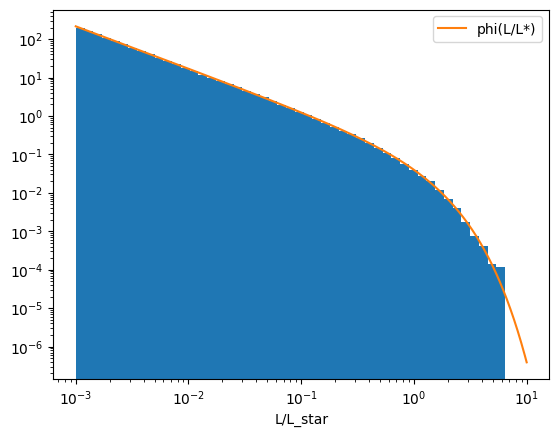

In [4]:
L_ratio = generate_schechter_lumRatio(npix, -1.1, 1e-3, 10)
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)
get_hist(L_ratio, xlabel='L/L_star', bins=bins, log=True, density=True)
plt.xscale('log');


L_test = np.logspace(-3, 1, 1000)
phi_test = proba_schechter_lumRatio(L_test, -1.1)
plt.plot(L_test, phi_test / np.trapz(phi_test, L_test), label = 'phi(L/L*)') #np.trapz ti normalize phi.
plt.legend();

### z, m, M, L, dL_mpc:

In [5]:
data = generate_lumMag(npix, to_table=True)
data

Number of rejects = 14600


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
0.8190933267655657,5327.591712774662,272070783.2067377,-16.256704767042493,27.375949906408295
1.4980861661996563,11195.424278191515,34198159.404031835,-14.005006830770208,31.24019595366247
0.7695091120775781,4935.599718952034,59860678.79801222,-14.61285409317822,28.853845560955584
1.7551538937709423,13595.637336987449,364851432.0022217,-16.5752901378767,29.091707718522404
0.8598102062032899,5654.073257586882,20707505.458727993,-13.460319461289545,30.301487694567832
0.9019070256815476,5995.7600402310245,91471321.1006454,-15.07321237888067,28.816008837990445
1.4477557260189673,10734.935717100057,2699543300.8616905,-18.74822574494182,26.405771495755886
2.6868136616757354,22809.452112966577,18223083.06899873,-13.321554637215561,33.46901963064663


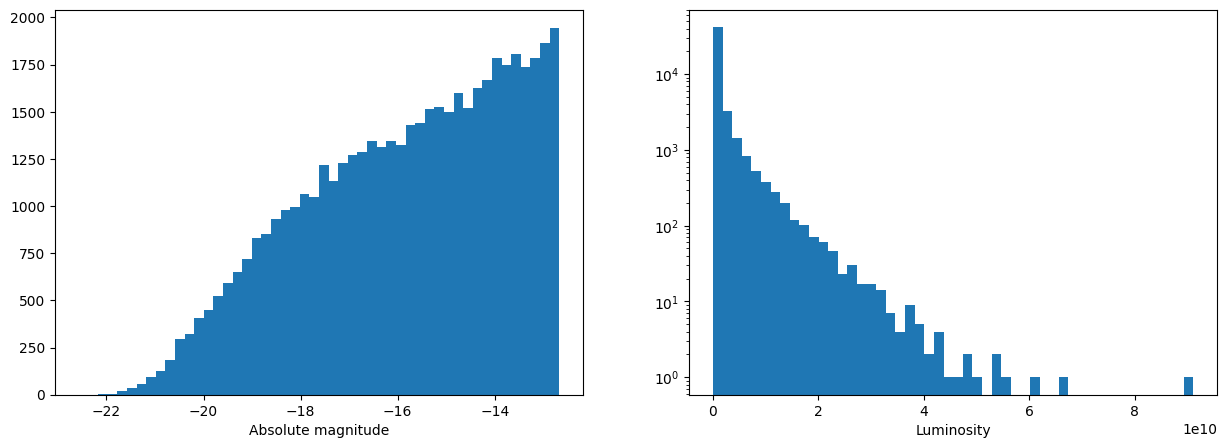

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=50, figax=(fig, ax[1]), log=True);

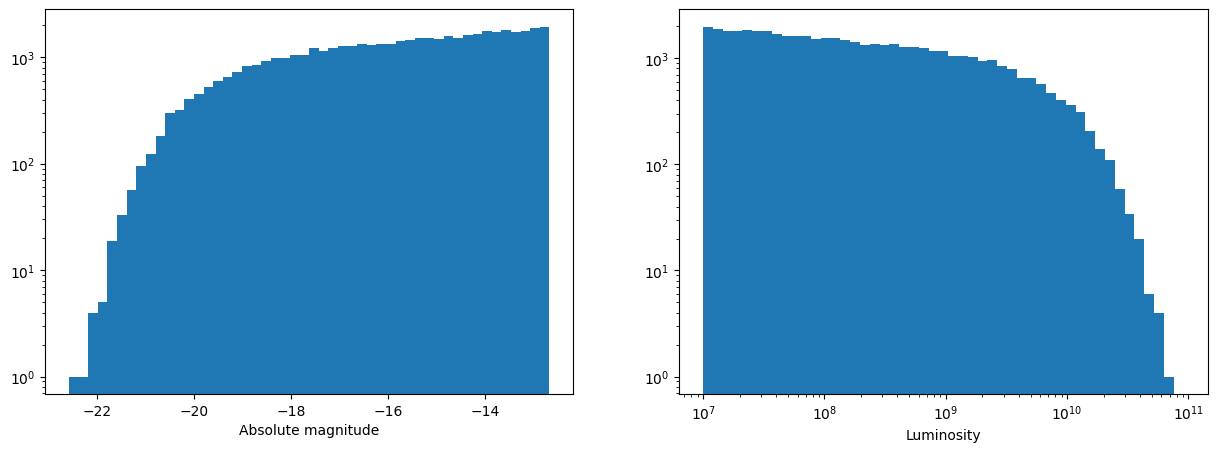

In [7]:
binsL = np.logspace(np.log10(np.min(data["L"])), np.log10(np.max(data["L"])), 50)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=binsL, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log');

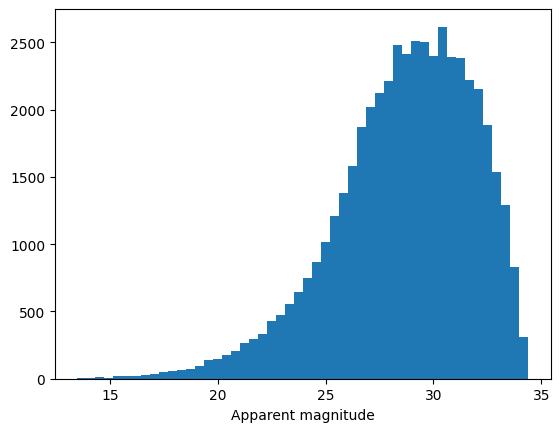

In [8]:
get_hist(data["m"], xlabel='Apparent magnitude', bins=50);

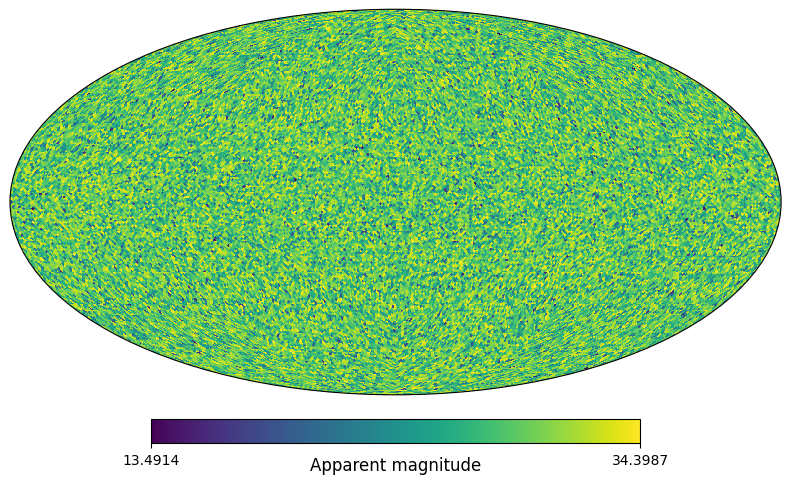

In [9]:
hp.projview(data["m"], unit="Apparent magnitude");

## $m_5$ magnitude

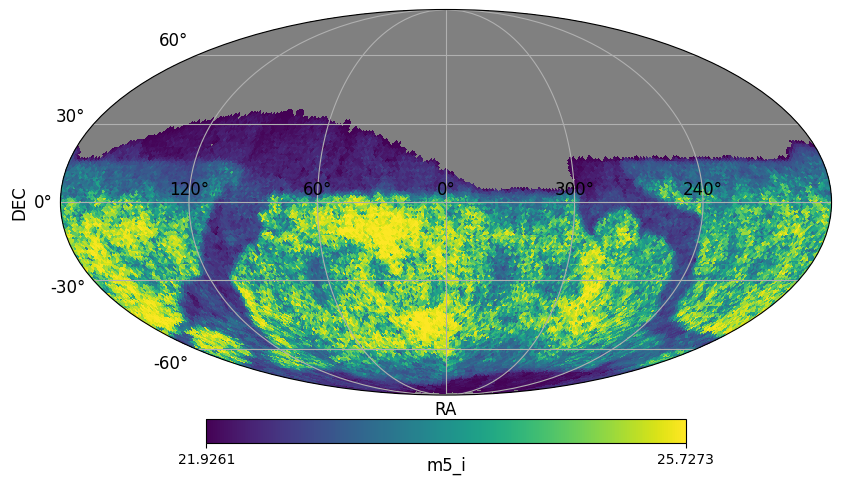

In [10]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'i'
dm.select_band(band)
dm.set_mask()
dm.plot()

## N sources sampling

In [11]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True)
dataN

Number of rejects = 295532


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
0.8398245722197227,5493.3181652647,486096406.7277805,-16.886806026847715,26.812367740530327
0.43061248179064204,2452.3044107535457,50700588.30363825,-14.432532496732817,27.515339399596854
2.5151979291544873,21063.11897620822,132201526.17023078,-15.473091171979268,31.14452223251069
0.8507287240021254,5580.907130897132,491285253.88665754,-16.898334322041897,26.83518965644851
2.8021726415184083,23993.634596316522,1546805626.457018,-18.143589357841194,28.756890845224802
1.6724381224309484,12815.027134015096,270755508.80178463,-16.25144325389786,29.28715439649532
2.8233232459293105,24211.605847195257,26004541.14244488,-13.707622987320741,33.21249498868741
0.6982142545515369,4383.42843186827,11033718242.672766,-20.27680472401923,22.932264877143602


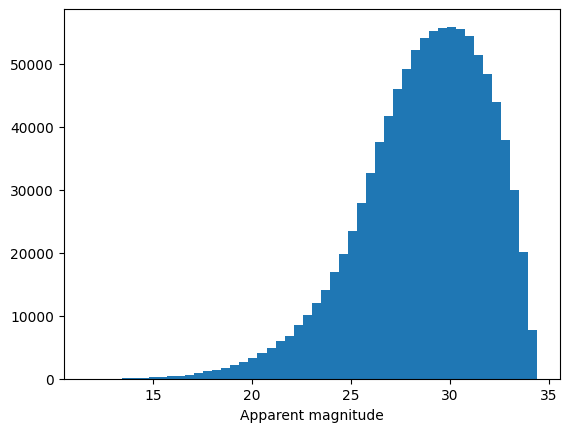

In [12]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50);

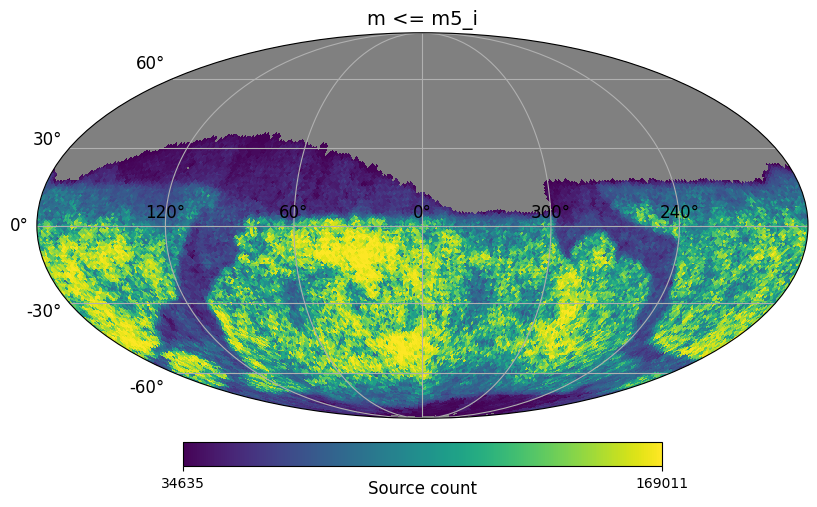

In [13]:
NSource_px = cut_m52map(dataN["m"], dm.m5i.copy())
NSource_px = hp.ma(NSource_px, badval=0)
hp.projview(NSource_px, nest=True, unit="Source count", title= "m <= m5_i", graticule=True, graticule_labels=True, norm="hist");

output_path = "Simul_Figures/Simul_Magnitude/CountMap_m5band_"
#get_savefig(plt, output_path, "i")

Unable to use minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.556e+08 (χ²/ndof = 3165.3)│              Nfcn = 275              │
│ EDM = 0.00476 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │114.8500e3 │ 0.0012e3  │            │            │    0    │         │       │
│ 1 │ A    │241.479e-3 │ 0.030e-3  │            │            │    0    │    1    │       │
│ 2 │ ra   │  0.05e3   │  0.34e3   │            │            │    0    │   360   │       │
│ 3 │ dec  │ -90.0000  │  0.0005   │            │            │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────────────────────────────────────┐
│     │                M                A               ra              dec │
├─────┼─────────────────────────────────────────────────────────────────────┤
│   M │             1.47      -11.9318e-6             -2.4      -209.34e-12 │
│   A │      -11.9318e-6         8.74e-10     -291.5774e-6        -0.03e-12 │
│  ra │             -2.4     -291.5774e-6          1.2e+07 1.04401850824e-3 │
│ dec │      -209.34e-12        -0.03e-12 1.04401850824e-3         9.11e-14 │
└─────┴─────────────────────────────────────────────────────────────────────┘

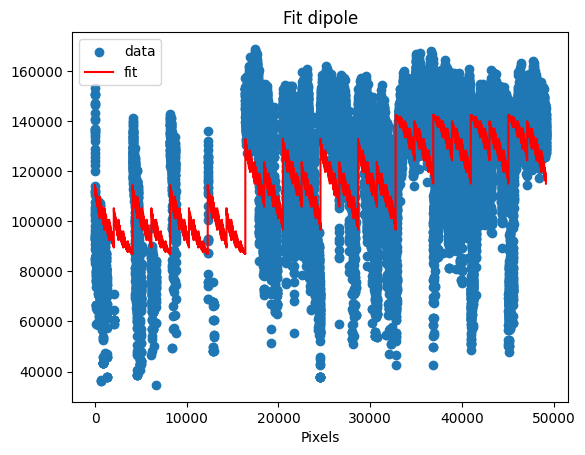

In [14]:
map = NSource_px 
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:92: RuntimeWarning: invalid value encountered in sqrt
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.802e+07 (χ²/ndof = 1791.0)│              Nfcn = 462              │
│ EDM = 1.62e-05 (Goal: 0.0002)    │            time = 4.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │121.2650e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │ 191.72e-3 │  0.05e-3  │  -0.05e-3  │  0.05e-3   │    0    │    1    │       │
│ 2 │ ra   │  264.28   │   0.05    │   -0.05    │    0.05    │    0    │   360   │       │
│ 3 │ dec  │  -79.634  │   0.009   │   -0.009   │   0.009    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.05e-3  │  0.05e-3  │   -0.05   │   0.05    │  -0.009   │   0.009   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │        8.02 -89.9325e-6      0.0118     8.30e-3 │
│   A │ -89.9325e-6    2.23e-09   -166.9e-9   -132.5e-9 │
│  ra │      0.0118   -166.9e-9     0.00258     0.02e-3 │
│ dec │     8.30e-3   -132.5e-9     0.02e-3    8.81e-05 │
└─────┴─────────────────────────────────────────────────┘

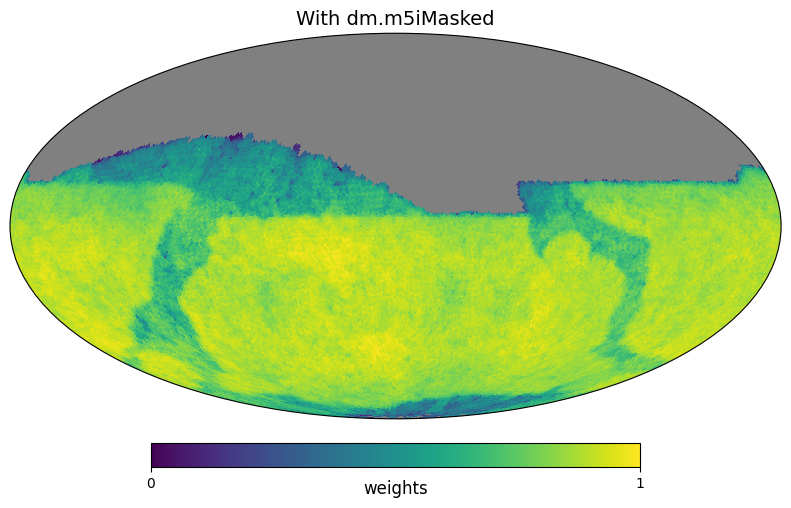

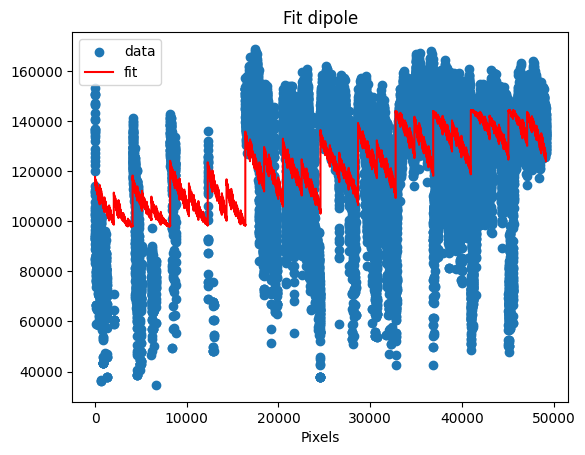

In [15]:
def renormalize(v):
    var=v.copy()
    var_min = var.min()
    var_max = var.max()
    return (var - var_min) / (var_max - var_min)


map = NSource_px
weights1 = renormalize(dm.m5iMasked)
hp.projview(weights1, nest=True, unit="weights", title= "With dm.m5iMasked");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights1)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.436e+08 (χ²/ndof = 2922.6)│              Nfcn = 550              │
│ EDM = 5.33e-05 (Goal: 0.0002)    │            time = 5.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │116.2989e3 │ 0.0024e3  │ -0.0024e3  │  0.0024e3  │    0    │         │       │
│ 1 │ A    │ 227.75e-3 │  0.04e-3  │  -0.04e-3  │  0.04e-3   │    0    │    1    │       │
│ 2 │ ra   │  258.16   │   0.04    │   -0.04    │    0.04    │    0    │   360   │       │
│ 3 │ dec  │  -78.396  │   0.007   │   -0.007   │   0.007    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.4    │    2.4    │ -0.04e-3  │  0.04e-3  │   -0.04   │   0.04    │  -0.007   │   0.007   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │        5.71 -61.1748e-6      0.0079     6.04e-3 │
│   A │ -61.1748e-6    1.69e-09   -115.2e-9   -102.2e-9 │
│  ra │      0.0079   -115.2e-9     0.00131     0.01e-3 │
│ dec │     6.04e-3   -102.2e-9     0.01e-3     5.5e-05 │
└─────┴─────────────────────────────────────────────────┘

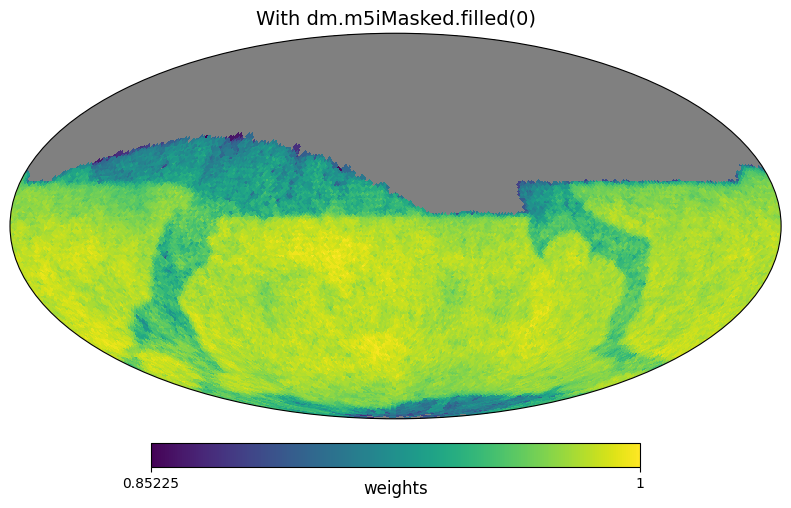

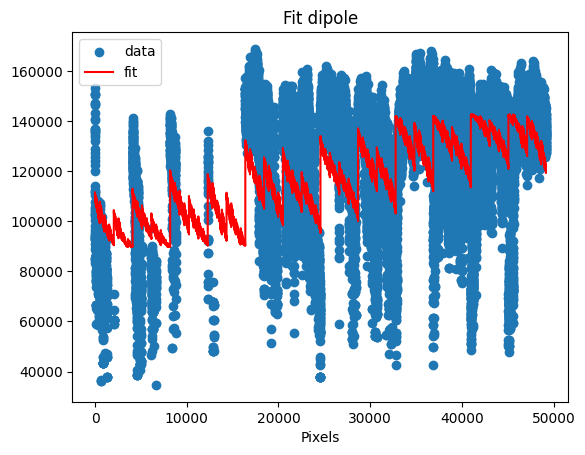

In [16]:
map = NSource_px
weights2 = renormalize(dm.m5iMasked.filled(0))
weights2 = hp.ma(weights2)
weights2.mask = dm.m5iMasked.mask
hp.projview(weights2, nest=True, unit="weights", title= "With dm.m5iMasked.filled(0)");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights2)
m

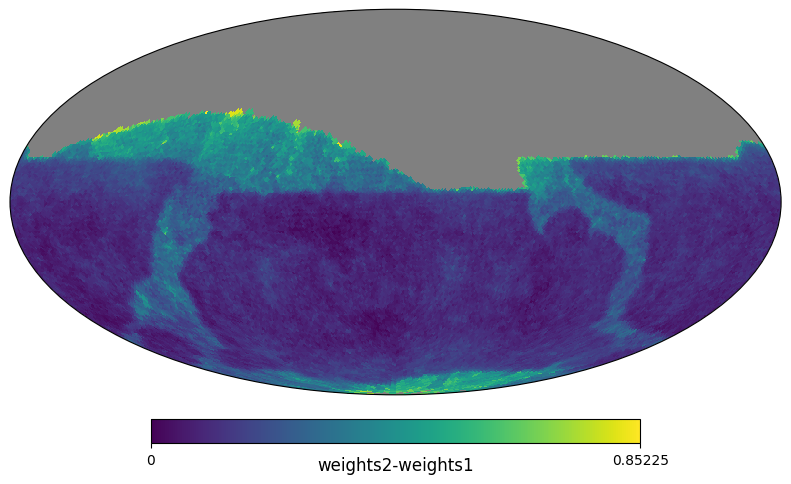

In [17]:
hp.projview(weights2-weights1, nest=True, unit="weights2-weights1", title= "");

## Poisson shot noise

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.447e+07 (χ²/ndof = 294.4)│              Nfcn = 462              │
│ EDM = 5.49e-06 (Goal: 0.0002)    │            time = 4.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │ 121.166e3 │  0.007e3  │  -0.007e3  │  0.007e3   │    0    │         │       │
│ 1 │ A    │ 195.47e-3 │  0.12e-3  │  -0.12e-3  │  0.12e-3   │    0    │    1    │       │
│ 2 │ ra   │  264.90   │   0.13    │   -0.13    │    0.13    │    0    │   360   │       │
│ 3 │ dec  │  -79.845  │   0.023   │   -0.023   │   0.023    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │ -0.12e-3  │  0.12e-3  │   -0.13   │   0.13    │  -0.023   │   0.023   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │        50.4 -567.759e-6       0.072     51.2e-3 │
│   A │ -567.759e-6     1.4e-08   -1.049e-6   -0.817e-6 │
│  ra │       0.072   -1.049e-6      0.0161      0.1e-3 │
│ dec │     51.2e-3   -0.817e-6      0.1e-3    0.000533 │
└─────┴─────────────────────────────────────────────────┘

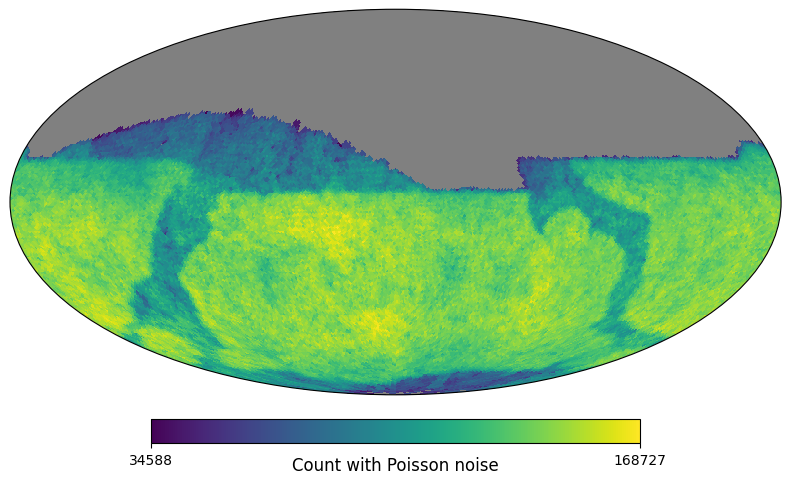

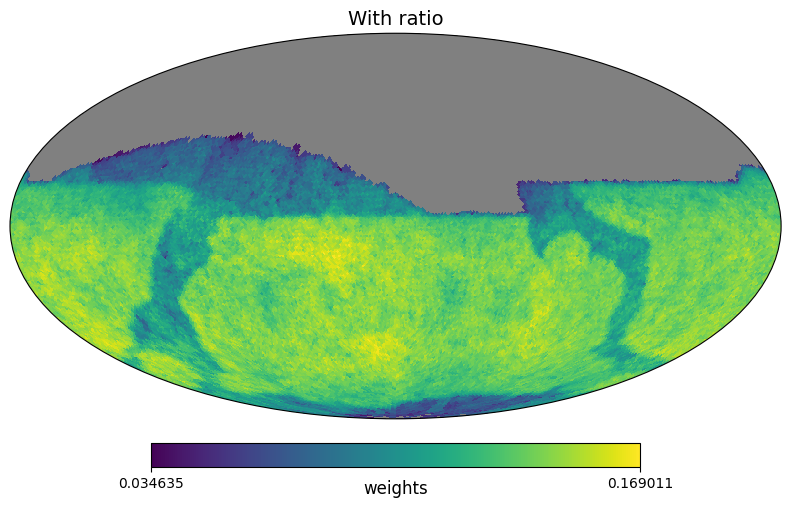

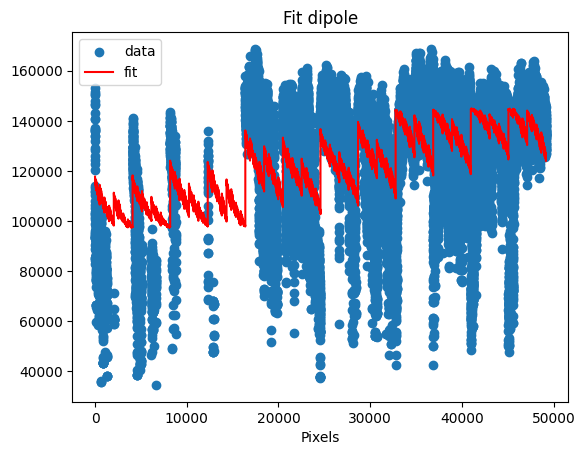

In [18]:
map = hp.ma(np.random.poisson(NSource_px), badval=0)
weights = NSource_px/NSource_px_th
hp.projview(map, nest=True, unit="Count with Poisson noise");
hp.projview(weights, nest=True, unit="weights", title= "With ratio");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.677e+07 (χ²/ndof = 1358.6)│              Nfcn = 999              │
│ EDM = 1.64e-05 (Goal: 0.0002)    │            time = 9.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │123.324576e3│0.000030e3 │-0.000030e3 │ 0.000030e3 │    0    │         │       │
│ 1 │ A    │177.5551e-3│ 0.0005e-3 │ -0.0005e-3 │ 0.0005e-3  │    0    │    1    │       │
│ 2 │ ra   │  0.03e3   │  0.21e3   │  -0.21e3   │   0.21e3   │    0    │   360   │       │
│ 3 │ dec  │-89.99999999994│0.00000102136│-0.00000000006│0.00000102136│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.03   │   0.03    │  -0.5e-6  │  0.5e-6   │  -0.21e3  │  0.21e3   │ -0.06e-9  │1021.36e-9 │
│  Valid   │   False   │   False   │   False   │   False   │   False   │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────────────────┐
│     │                  M                  A                 ra                dec │
├─────┼─────────────────────────────────────────────────────────────────────────────┤
│   M │           0.000904          -1.91e-12             0.4e-3           0.16e-15 │
│   A │          -1.91e-12           2.55e-13        34.44695e-9                  0 │
│  ra │             0.4e-3        34.44695e-9           1.79e+09 660.81229274229e-6 │
│ dec │           0.16e-15                  0 660.81229274229e-6           2.45e-16 │
└─────┴─────────────────────────────────────────────────────────────────────────────┘

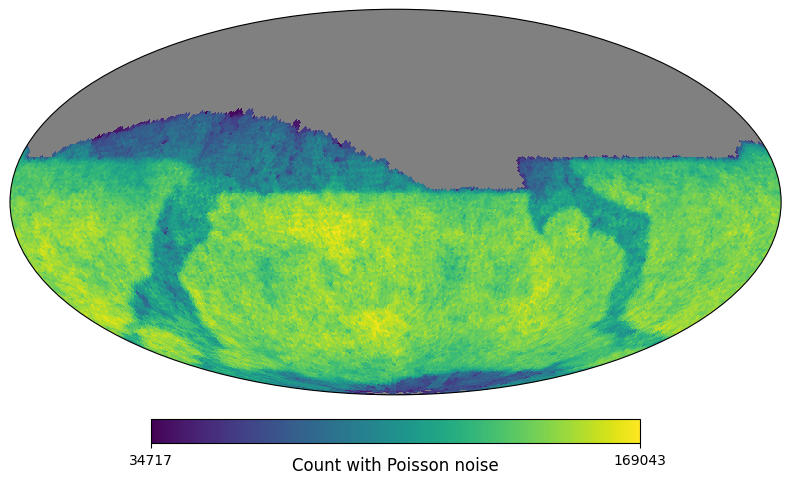

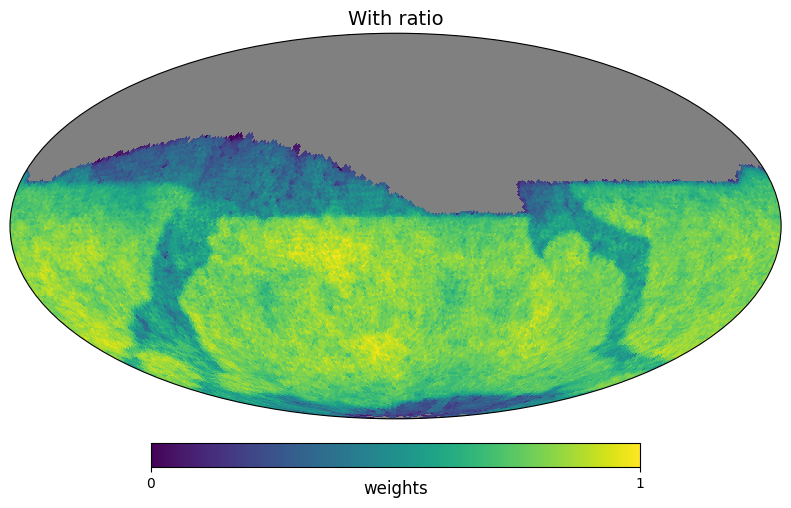

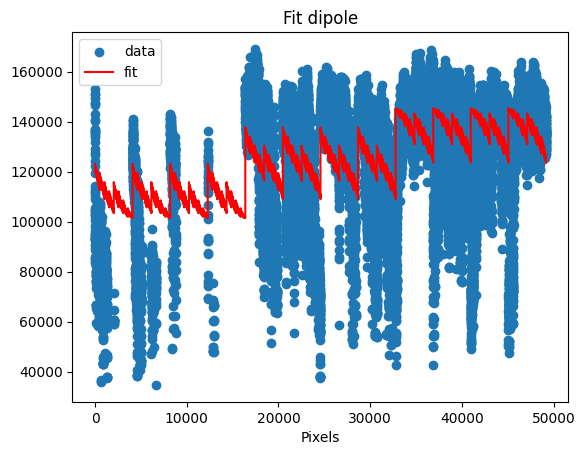

In [19]:
map = hp.ma(np.random.poisson(NSource_px), badval=0)
weights = NSource_px/NSource_px_th
weights = renormalize(weights)
hp.projview(map, nest=True, unit="Count with Poisson noise");
hp.projview(weights, nest=True, unit="weights", title= "With ratio");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights)
m